# Análise de Tempo, Energia e Memória do QuickSort com Pandas e Criação de Gráfico
Importando a biblioteca pandas e matplotlib

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

Carregando o CSV

In [6]:
df = pd.read_csv("../Resultados preliminares/10000000.csv")

# Visualizar primeiras linhas
print(df.head())

    vector_type algorithm      size  time_ms  stress  ram_kb_max  \
0      endnoise  HeapSort  10000000  4490.67     NaN       42944   
1       ordered  HeapSort  10000000  3942.80     NaN       42948   
2  random_swaps  HeapSort  10000000  4109.08     NaN       42944   
3        random  HeapSort  10000000  6796.72     NaN       42904   
4  repeated_1_5  HeapSort  10000000  3393.87     NaN       42900   

   ram_kb_media  energy_j  
0         42811  111.3100  
1         42815  150.0890  
2         42811  148.3980  
3         42771  229.0000  
4         42767   92.8636  


Filtrando apenas QuickSort

In [7]:
quick = df[df["algorithm"] == "QuickSort"]

print(quick.head())

     vector_type  algorithm      size     time_ms  stress  ram_kb_max  \
16      endnoise  QuickSort  10000000  170663.000     NaN       43124   
17       ordered  QuickSort  10000000  173452.000     NaN       43136   
18  random_swaps  QuickSort  10000000    3170.280     NaN       42916   
19        random  QuickSort  10000000    3964.310     NaN       42932   
20  repeated_1_5  QuickSort  10000000     284.486     NaN       42944   

    ram_kb_media    energy_j  
16         42929  4419.79000  
17         42929  4853.54000  
18         42783   110.76100  
19         42799    99.49380  
20         42809     7.63835  


Calculando média do tempo por tipo de vetor

In [10]:
quick_media = (
    quick.groupby("vector_type")["time_ms"]
    .mean()
    .sort_values()
)

print(quick_media)

vector_type
repeated            32.1815
repeated_1_5       284.4860
random_swaps      3170.2800
random            3964.3100
zigzag           12545.0000
reversed        126626.0000
endnoise        170663.0000
ordered         173452.0000
Name: time_ms, dtype: float64


Criando gráfico

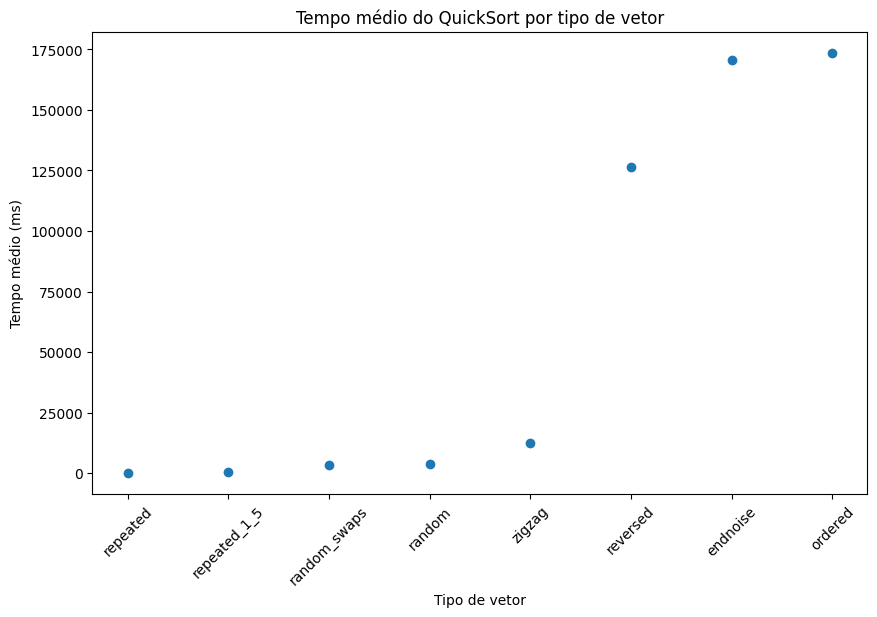

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(quick_media.index, quick_media.values)

plt.xlabel("Tipo de vetor")
plt.ylabel("Tempo médio (ms)")
plt.title("Tempo médio do QuickSort por tipo de vetor")

plt.xticks(rotation=45)

plt.show()

Consumo de energia por tipo de vetor

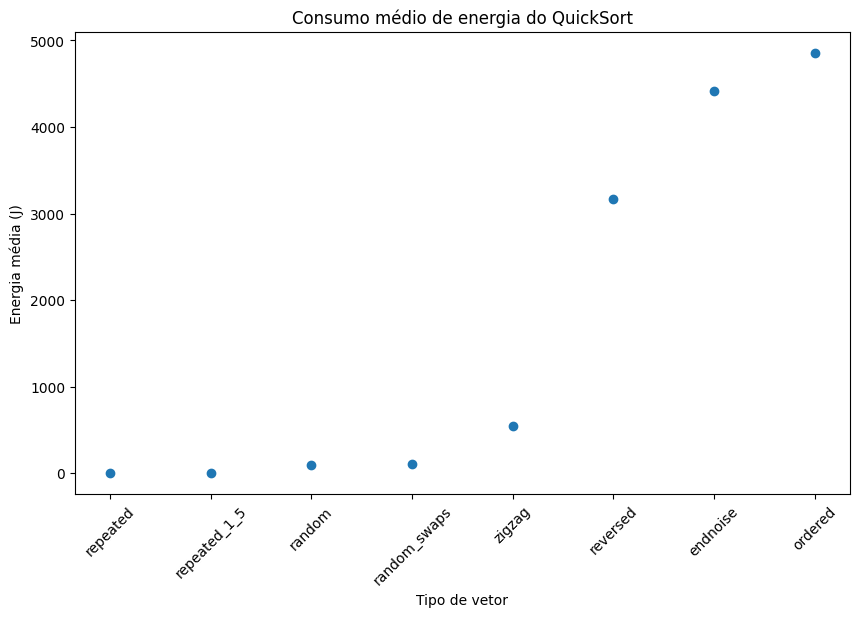

In [ ]:
#Calcula Média de energia consumida por tipo de vetor para o QuickSort
energia_media = (
    quick.groupby("vector_type")["energy_j"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.scatter(energia_media.index, energia_media.values)

plt.xlabel("Tipo de vetor")
plt.ylabel("Energia média (J)")
plt.title("Consumo médio de energia do QuickSort")

plt.xticks(rotation=45)

plt.show()

Uso de RAM por tipo de vetor

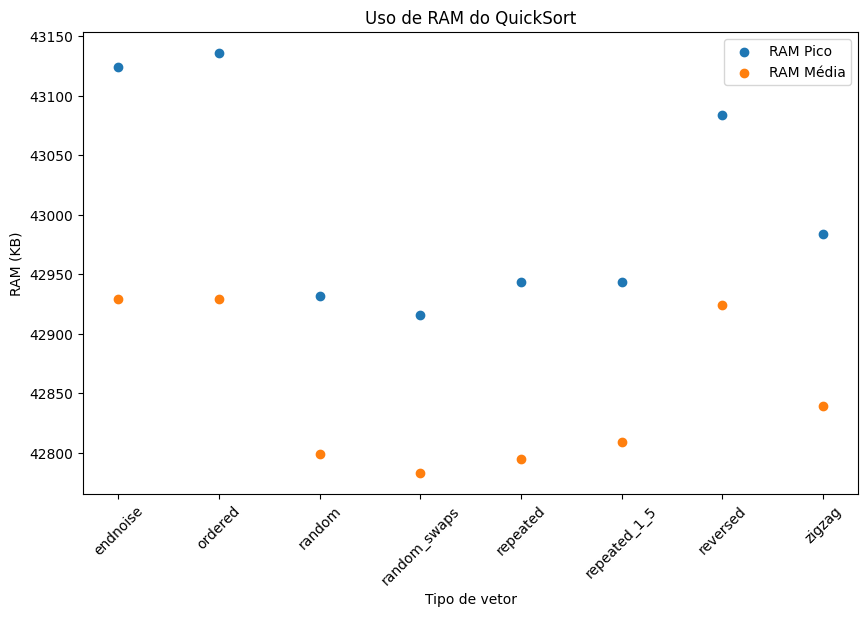

In [13]:
ram_media = (
    quick.groupby("vector_type")[["ram_kb_max", "ram_kb_media"]]
    .mean()
)

plt.figure(figsize=(10, 6))

# Pico de RAM
plt.scatter(ram_media.index, ram_media["ram_kb_max"], label="RAM Pico")

# Média de RAM
plt.scatter(ram_media.index, ram_media["ram_kb_media"], label="RAM Média")

plt.xlabel("Tipo de vetor")
plt.ylabel("RAM (KB)")
plt.title("Uso de RAM do QuickSort")

plt.legend()
plt.xticks(rotation=45)

plt.show()